<a href="https://colab.research.google.com/github/Danishkodavanti/ML_Lab/blob/main/ML_LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

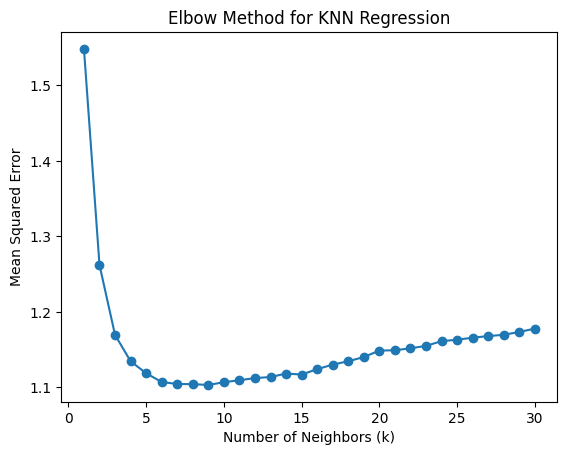

Optimal k found: 9
RMSE: 1.0322938633531986
R² Score: 0.1867953913539413
Prediction for new point: [2.42805487]


In [ ]:
#KNN Regression program

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 0: Load dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 1: Elbow Method to find optimal k
errors = []
k_values = range(1, 31)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_val = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_val)
    errors.append(mse)

# Plot error vs k
plt.plot(k_values, errors, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error')
plt.title('Elbow Method for KNN Regression')
plt.show()

# Step 2: Choose optimal k (minimum error)
optimal_k = k_values[np.argmin(errors)]
print("Optimal k found:", optimal_k)

# Step 3: Train final KNN model with optimal k
knn = KNeighborsRegressor(n_neighbors=optimal_k, weights='distance')
knn.fit(X_train, y_train)

# Step 4: Predict on test set
y_pred = knn.predict(X_test)

# Step 5: Evaluate performance
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

# Step 6: Predict for a NEW point (example)
# Suppose we want to predict for a new house with given features:
new_point = np.array([[8.3252, 41.0, 6.9841, 1.0238, 322.0, 2.5556, 37.88, -122.23]])
prediction = knn.predict(new_point)
print("Prediction for new point:", prediction)